In [1]:
#线性模型：给定n维输入，X=[x1,x2.....xn]T,有一个n维权重W=[w1,w2....wn]T,以及一个偏差b
#输出y=w1x1+w2x2+.........wnxn+b
#向量表示 y=<w,x>+b
#线性模型可以视为单层神经网络

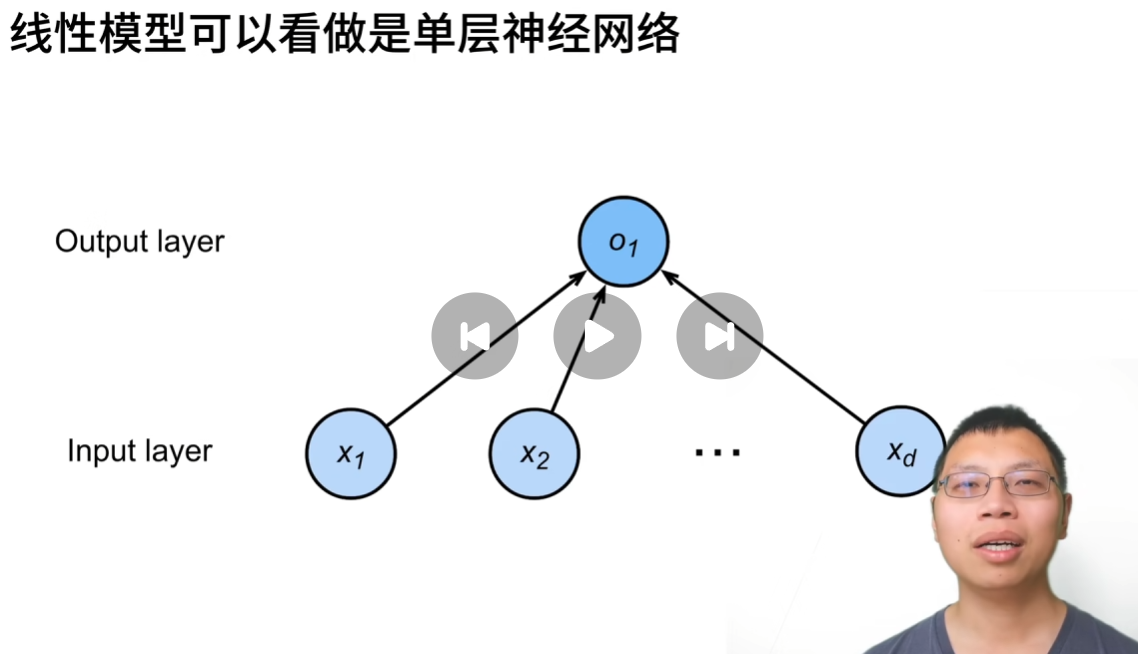

In [2]:
#衡量估计质量 比较估计值和预估值
#l(y_real,y_pred)=0.5*(y_real-y_pred)**2 平方损失
#训练损失： l(x,y,w,b)=1/2n∑(yi-<xi,w>-b)**2
#最小化损失来确定学习参数


In [3]:
#基础优化方法
#梯度下降：模型没有显式解时，随机挑选参数，沿梯度方向增加损失函数值，不断更新参数使其靠近最优解
#学习率lr:步长的超参数

#小批量随机梯度下降 ：采用随机b个样本来近似总体损失 1/b ∑l(xi,yi,w) b为超参数

In [4]:
#线性回归从0开始实现

%matplotlib inline
import random
import torch
from d2l import torch as d2l


In [5]:
#造数据
def synthetic_data(w,b,num_examples):
    """生成y=Xw+b+噪声"""
    x=torch.normal(0,1,(num_examples,len(w)))
    y=torch.matmul(x,w)+b
    y+=torch.normal(0,0.01,y.shape)
    return x,y.reshape((-1,1))  #作为列向量返回

true_w = torch.tensor([2,-3.4])
true_b=4.2
features,labels = synthetic_data(true_w,true_b,1000)

In [6]:
print(f"features:{features[0]},labels:{labels[0]}")

features:tensor([-1.2439, -1.0481]),labels:tensor([5.2605])


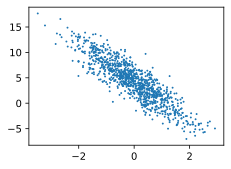

In [8]:
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach().numpy(),labels.detach().numpy(),1)

In [11]:
#定义函数，接受批量大小，特征矩阵和标签矩阵和标签向量作为输入，生成大小为batch_size的小批量
def data_iter(batch_size,features,labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    #随机读取样本，没有特定顺序
    random.shuffle(indices)
    for i in range(0,num_examples,batch_size):
        batch_indices=torch.tensor(indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]

batch_size=10

for x,y in data_iter(batch_size,features,labels):
    print(x,'\n',y)
    break

tensor([[-1.7411, -1.0113],
        [-0.2215,  0.7542],
        [-0.4616, -2.1240],
        [ 1.3372, -1.0290],
        [-0.6013,  2.5480],
        [ 0.2258, -0.0962],
        [-0.1873,  0.8064],
        [-0.6301,  0.9465],
        [ 0.5334, -1.5032],
        [ 0.8902, -0.3021]]) 
 tensor([[ 4.1598],
        [ 1.1986],
        [10.4947],
        [10.3816],
        [-5.6624],
        [ 4.9834],
        [ 1.0975],
        [-0.2669],
        [10.4006],
        [ 7.0154]])


In [14]:
w=torch.normal(0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)

In [15]:
def linreg(x,w,b):
    return torch.matmul(x,w)+b

In [16]:
def squared_loss(y_hat,y):
    return (y_hat-y.reshape(y_hat.shape))**2/2

def sgd(params,lr,batch_size):
    with torch.no_grad():
        for param in params:
            param-=lr*param.grad/batch_size
            param.grad.zero_()

In [20]:
lr =0.03
num_epochs=10
net=linreg
loss =squared_loss

for epoch in range(num_epochs):
    for x,y in data_iter(batch_size,features,labels):
        l = loss(net(x,w,b),y)
        l.sum().backward()
        sgd([w,b],lr,batch_size)
    with torch.no_grad():
        train_l = loss(net(features,w,b),labels)
        print(f'epoch{epoch+1},loss{float(train_l.mean()):f}')

epoch1,loss0.000049
epoch2,loss0.000050
epoch3,loss0.000049
epoch4,loss0.000049
epoch5,loss0.000050
epoch6,loss0.000049
epoch7,loss0.000050
epoch8,loss0.000050
epoch9,loss0.000049
epoch10,loss0.000049


In [21]:
print(f'true_w_diff:{true_w-w.reshape(true_w.shape)}')
print(f'true_b_diff:{true_b-b}')

true_w_diff:tensor([0.0006, 0.0003], grad_fn=<SubBackward0>)
true_b_diff:tensor([-0.0002], grad_fn=<RsubBackward1>)


In [2]:
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

true_w = torch.tensor([2,-3.4])
true_b = 4.2
features,labels = d2l.synthetic_data(true_w,true_b,1000)

def load_array(data_arrays,batch_size,is_train=True):
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset,batch_size,shuffle= is_train)

batch_size=10
data_iter = load_array((features,labels),batch_size)

next(iter(data_iter))

[tensor([[-0.0460, -0.9597],
         [-1.1859, -2.1134],
         [ 0.2014,  0.2431],
         [-0.9285, -1.1686],
         [-0.3178,  0.6291],
         [ 1.6182,  0.0747],
         [-1.3460, -0.1553],
         [ 0.2436, -0.7082],
         [ 1.8486, -0.3246],
         [ 0.5692,  1.5063]]),
 tensor([[7.3780],
         [9.0206],
         [3.7790],
         [6.3252],
         [1.4176],
         [7.1730],
         [2.0321],
         [7.0956],
         [8.9987],
         [0.2081]])]

In [8]:
from torch import nn #神经网络缩写为nn

#初始化模型参数
net = nn.Sequential(nn.Linear(2,1))
net[0].weight.data.normal_(0,0.01)
net[0].bias.data.fill_(0)

#均方误差
loss = nn.MSELoss()
trainer = torch.optim.SGD(net.parameters(),lr=0.3)

In [9]:
num_epochs=3
for epoch in range(num_epochs):
    for x,y in data_iter:
        l =loss(net(x),y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features),labels)
    print(f'epoch{epoch+1},loss{l:f}')
    

epoch1,loss0.000109
epoch2,loss0.000115
epoch3,loss0.000106
